# 01 — EDA: universe, history coverage

**Inputs:** `data/clean/*.parquet`, `data/panel/prices.parquet`.

**Outputs for the deck:** per-ticker history-length bar, common-window calendar, log-price small-multiples.

Window: `config.START_DATE = "2015-01-01"` through today (≈11 years of daily bars). The Turkish-lira 1M-to-1 redenomination (2005-01-03) sits before the window, so the split-adjustment step in `src/data/clean.py` is a no-op on this slice and no longer needs an EDA figure.

Helpers live in `src.plots.figures`. Run from the project root so relative imports resolve.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.plots.figures import apply_style
from config import BIST100_CONSTITUENTS, BIST100_INDEX_TICKER, CLEAN_DIR, PANEL_DIR, START_DATE

apply_style()
print(f"Window start: {START_DATE}")

Window start: 2018-01-01


## 1. Universe inventory

Which tickers cleared the `MIN_HISTORY_DAYS=750` filter? Which from `BIST100_CONSTITUENTS` are missing (yfinance ticker remapping needed)?

In [2]:
cleaned = {p.stem: p for p in sorted(CLEAN_DIR.glob("*.parquet"))}
const_present = [t for t in BIST100_CONSTITUENTS if t in cleaned]
const_missing = [t for t in BIST100_CONSTITUENTS if t not in cleaned]
index_present = BIST100_INDEX_TICKER in cleaned

print(f"BIST100_CONSTITUENTS in config:  {len(BIST100_CONSTITUENTS)}")
print(f"Cleaned constituents on disk:    {len(const_present)}")
print(f"Index on disk ({BIST100_INDEX_TICKER}):     {index_present}")
print(f"Missing from clean/: {const_missing}")

BIST100_CONSTITUENTS in config:  100
Cleaned constituents on disk:    83
Index on disk (XU100.IS):     True
Missing from clean/: ['ALTNY.IS', 'BALSU.IS', 'DSTKF.IS', 'EFOR.IS', 'ENERY.IS', 'GLRMK.IS', 'GRTHO.IS', 'IZENR.IS', 'KLRHO.IS', 'KTLEV.IS', 'OBAMS.IS', 'PAHOL.IS', 'PASEU.IS', 'PATEK.IS', 'REEDR.IS', 'TABGD.IS', 'TRMET.IS']


## 2. Per-ticker history length

Bar chart of bars-per-ticker. With a uniform `START_DATE = 2015-01-01` all 30 surviving constituents share essentially the same length (≈2907 bars); the chart is now a sanity check that no name was silently dropped by the `MIN_HISTORY_DAYS = 750` filter, rather than a way to flag late-IPO names.

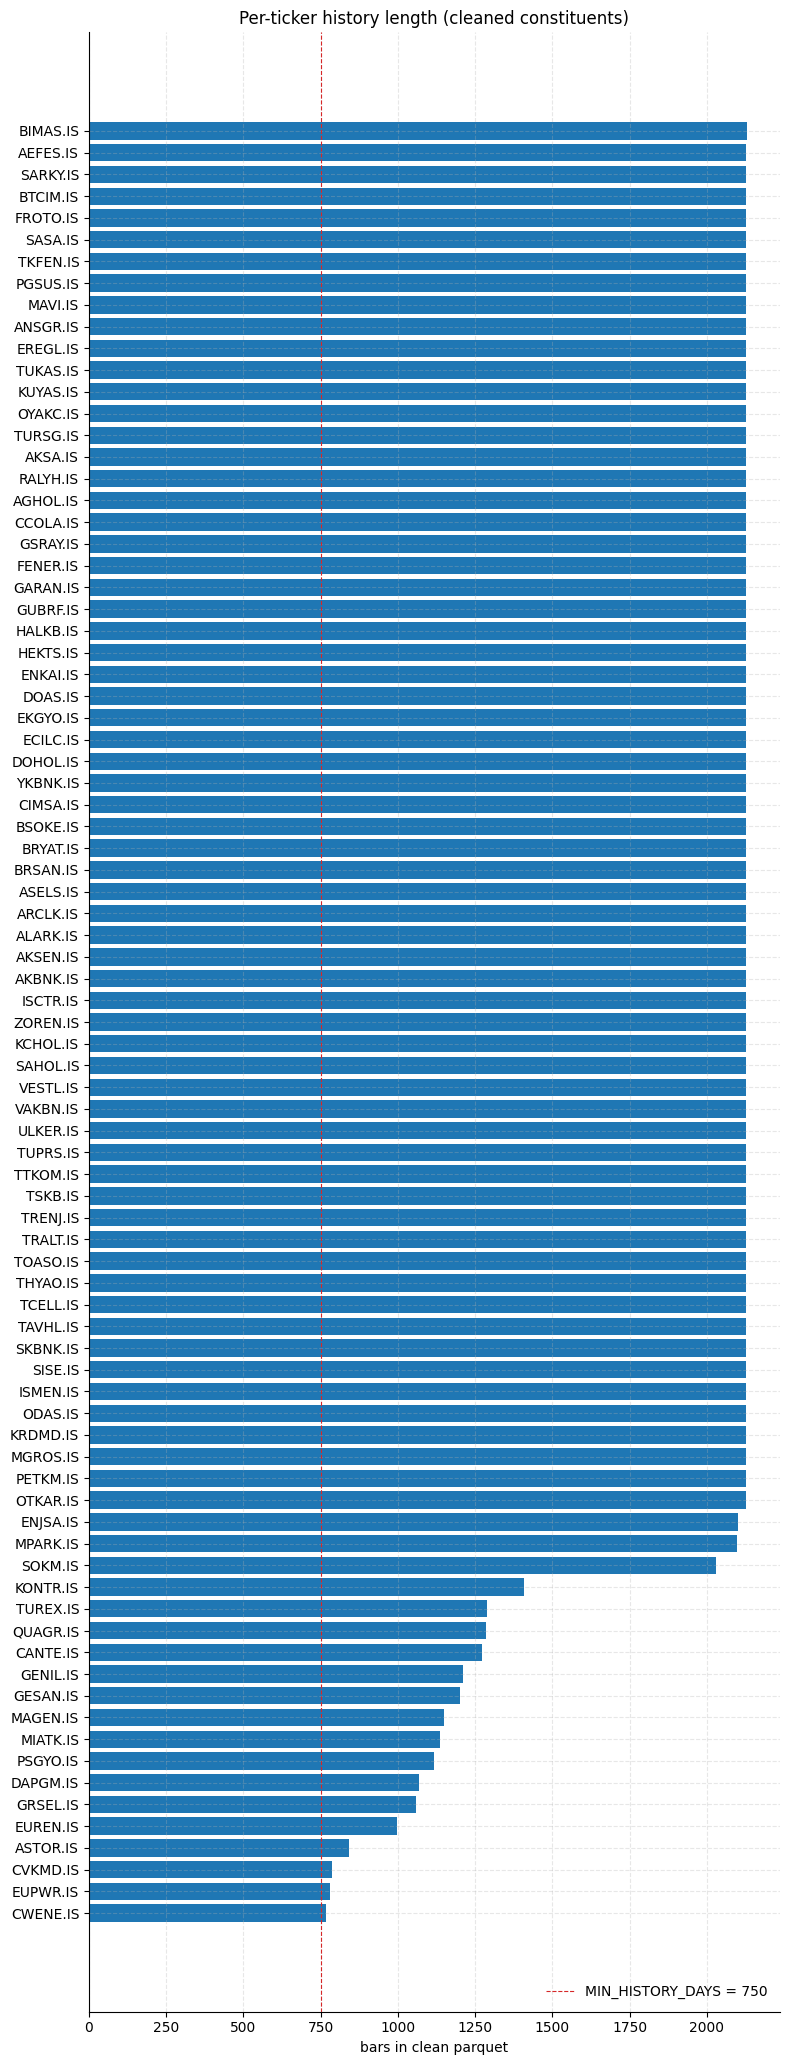


Shortest history: CWENE.IS (768 bars)
Longest:          BIMAS.IS (2130 bars)


In [3]:
rows = []
for ticker in const_present:
    df = pd.read_parquet(cleaned[ticker])
    rows.append({"ticker": ticker, "n_bars": len(df),
                 "first": df.index.min(), "last": df.index.max()})
hist = pd.DataFrame(rows).sort_values("n_bars")

fig, ax = plt.subplots(figsize=(8, max(4, 0.25 * len(hist))))
ax.barh(hist["ticker"], hist["n_bars"], color="C0")
ax.axvline(750, color="C3", linestyle="--", linewidth=0.8,
           label="MIN_HISTORY_DAYS = 750")
ax.set_xlabel("bars in clean parquet")
ax.set_title("Per-ticker history length (cleaned constituents)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"\nShortest history: {hist.iloc[0]['ticker']} ({hist.iloc[0]['n_bars']} bars)")
print(f"Longest:          {hist.iloc[-1]['ticker']} ({hist.iloc[-1]['n_bars']} bars)")

## 3. Common date range and missing-bar counts

First / last date per ticker; count of NaN closes inside the active window.

In [4]:
panel_close = pd.read_parquet(PANEL_DIR / "prices.parquet")
print(f"Panel shape: {panel_close.shape}")
print(f"Panel range: {panel_close.index.min().date()} → {panel_close.index.max().date()}")

missing = panel_close.isna().sum().sort_values(ascending=False)
missing.name = "missing_close"
nonzero_missing = missing[missing > 0]
print(f"\nTickers with ≥1 missing close in the common panel: {len(nonzero_missing)}")
print(nonzero_missing.head(10).to_string())

start_end = pd.DataFrame({
    "first_valid": panel_close.apply(lambda c: c.first_valid_index()),
    "last_valid":  panel_close.apply(lambda c: c.last_valid_index()),
})
start_end["years"] = (start_end["last_valid"] - start_end["first_valid"]).dt.days / 365.25
print("\nFirst/last valid bar per ticker (head):")
print(start_end.sort_values("first_valid").head(8).round({"years": 1}).to_string())

Panel shape: (2130, 83)
Panel range: 2018-01-01 → 2026-06-02

Tickers with ≥1 missing close in the common panel: 82
ticker
CWENE.IS    1362
EUPWR.IS    1350
CVKMD.IS    1345
ASTOR.IS    1289
EUREN.IS    1132
GRSEL.IS    1071
DAPGM.IS    1062
PSGYO.IS    1012
MIATK.IS     995
MAGEN.IS     980

First/last valid bar per ticker (head):
         first_valid last_valid  years
ticker                                
AEFES.IS  2018-01-01 2026-06-02    8.4
SAHOL.IS  2018-01-01 2026-06-02    8.4
RALYH.IS  2018-01-01 2026-06-02    8.4
PGSUS.IS  2018-01-01 2026-06-02    8.4
PETKM.IS  2018-01-01 2026-06-02    8.4
OYAKC.IS  2018-01-01 2026-06-02    8.4
OTKAR.IS  2018-01-01 2026-06-02    8.4
ODAS.IS   2018-01-01 2026-06-02    8.4


## 4. Log-price overview

Small-multiples of log-close per ticker so the reader sees the broad regime shifts in the 2015→present window (2018 TL crisis, 2020 COVID drawdown and recovery, 2022–24 inflation regime) at a glance.

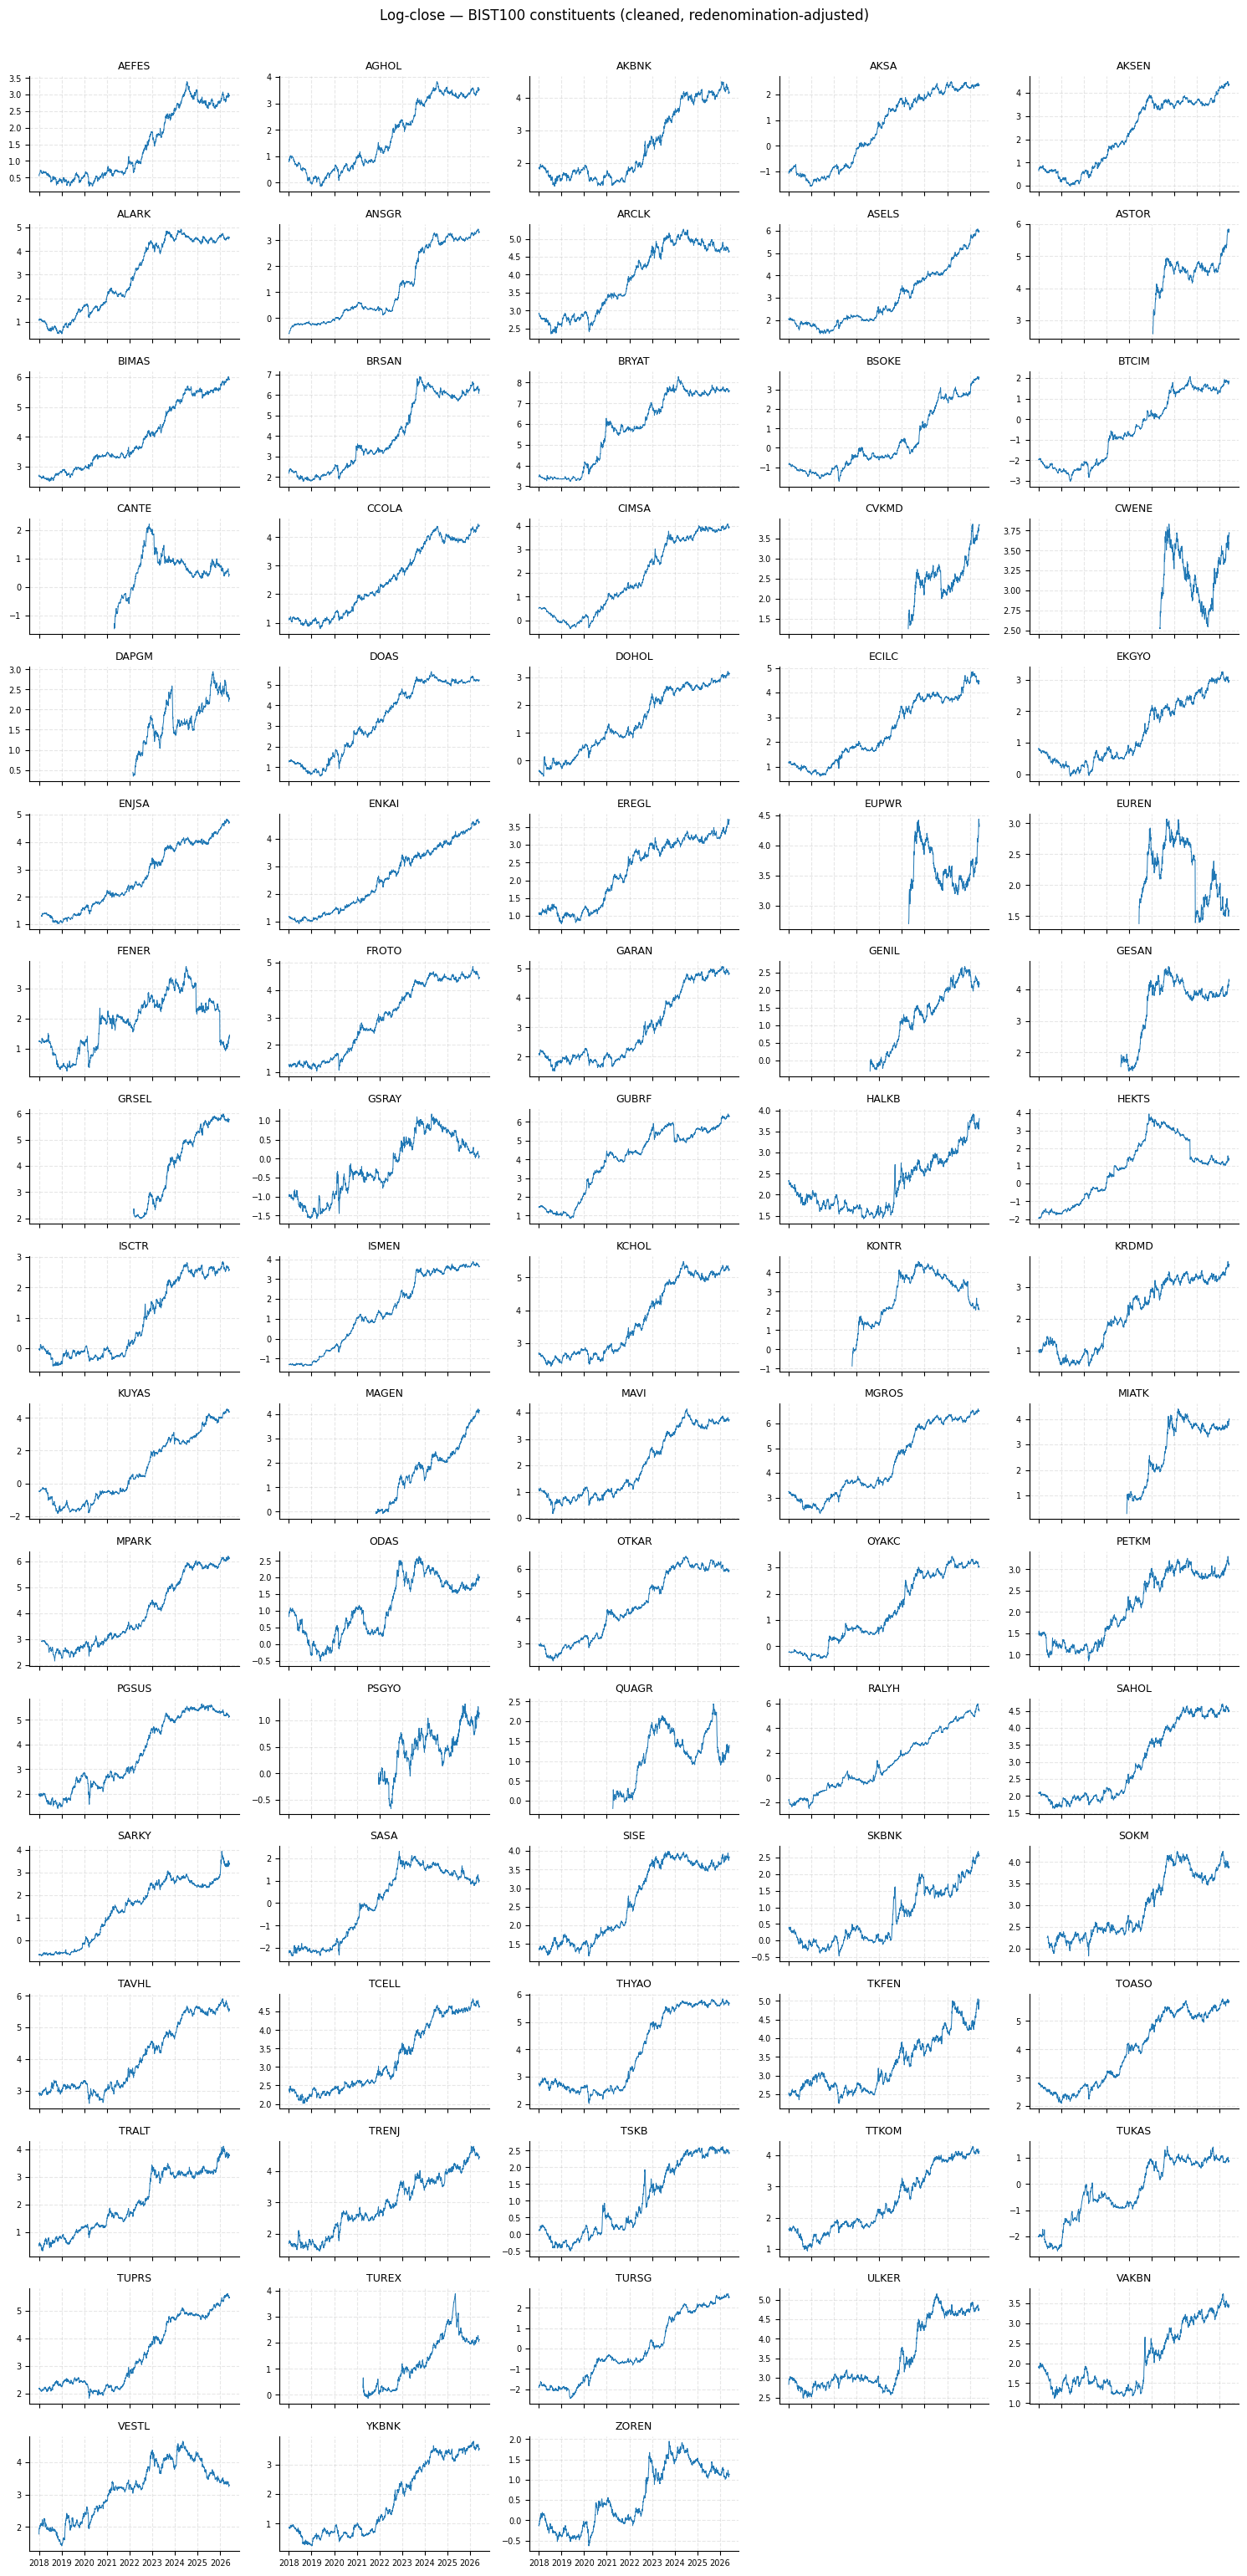

In [5]:
tickers_sorted = sorted(const_present)
ncol = 5
nrow = int(np.ceil(len(tickers_sorted) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3 * ncol, 1.8 * nrow), sharex=True)
axes = axes.flatten()
for i, ticker in enumerate(tickers_sorted):
    df = pd.read_parquet(cleaned[ticker])
    axes[i].plot(df.index, np.log(df["close"]), linewidth=0.7, color="C0")
    axes[i].set_title(ticker.replace(".IS", ""), fontsize=9)
    axes[i].tick_params(labelsize=7)
for j in range(len(tickers_sorted), len(axes)):
    axes[j].set_visible(False)
fig.suptitle("Log-close — BIST100 constituents (cleaned, redenomination-adjusted)", y=1.005)
plt.tight_layout()
plt.show()